In [1]:
!pip install astroquery

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.1 MB 4.5 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/11.1 MB 4.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.1 MB 4.1 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.1 MB 3.5 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.1 MB 3.0 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.1 MB 3.0 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.1 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 2.3 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/11.1 MB 2.2 MB/s eta 0:00:04
   ---------------- ----------------------- 4.5/11.1 MB 2.2 MB/s eta 0:00:04
   ----------

In [2]:
import matplotlib.pyplot as plt

In [3]:
from astroquery.skyview import SkyView

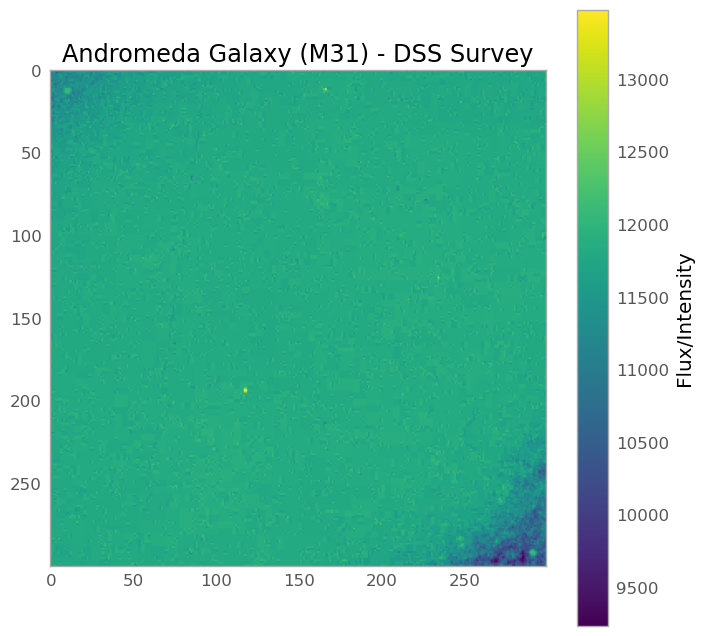

In [6]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

if 'hdu' in locals():
    plt.figure(figsize=(8,8))
    plt.imshow(hdu.data, cmap='viridis') 
    plt.colorbar(label='Flux/Intensity')
    plt.title("Andromeda Galaxy (M31) - DSS Survey")
    plt.grid(False) 
    plt.show()
else:
    print("Check your connection; SkyView is not returning data.")

In [7]:
M31_header = hdu.header
print(repr(M31_header))

SIMPLE  =                    T / Written by SkyView Mon May 04 21:52:16 EDT 2026
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                  300 / Width of image                                 
NAXIS2  =                  300 / Height of image                                
CRVAL1  =              10.6847 / Reference longitude                            
CRVAL2  =              41.2688 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                150.5 / X reference pixel                              
CRPIX2  =                150

In [8]:
M31_Pixels = hdu.data

In [9]:
type(M31_Pixels)

numpy.ndarray

In [10]:
M31_Pixels.shape

(300, 300)

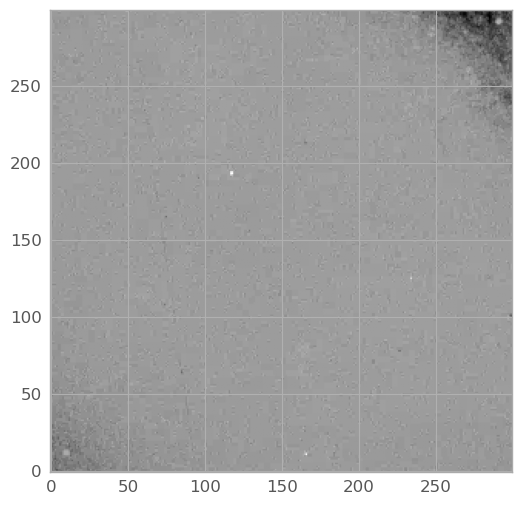

In [11]:
plt.imshow(M31_Pixels, cmap='gray', origin='lower')

In [12]:
import astropy.units as u

In [13]:
hdu = SkyView.get_images("M31", "DSS2 Blue",
                         pixels=600,
                         radius=150*u.arcmin)[0][0]

In [14]:
M31_DSS2_Blue_Pixels = hdu.data

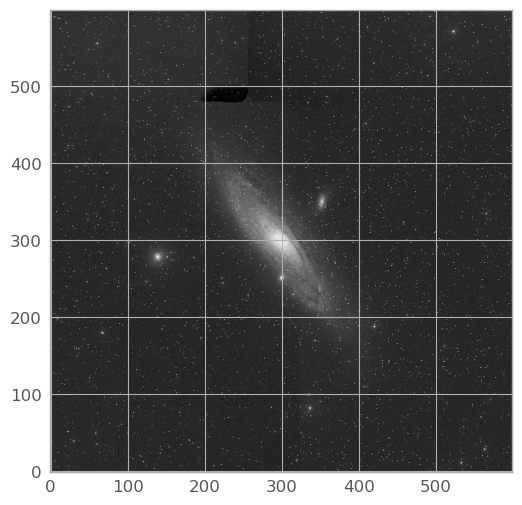

In [15]:
plt.imshow(M31_DSS2_Blue_Pixels, cmap='gray', origin='lower')

In [16]:
# IMPORT FITS FROM IO MODULE OF ASTROPY
from astropy.io import fits

In [19]:
hdulist = fits.HDUList()
hdu1 = fits.PrimaryHDU()
hdu1.data = M31_Pixels
hdu1.header = M31_header
hdulist.append(hdu1)
hdulist.writeto('my_andromeda_test.fits')

In [20]:
My_fits = fits.open('my_andromeda_test.fits')
print(My_fits.info())

Filename: my_andromeda_test.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     172   (300, 300)   float32   
None


In [21]:
My_fits[0].header

SIMPLE  =                    T / Written by SkyView Mon May 04 21:52:16 EDT 2026
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                  300 / Width of image                                 
NAXIS2  =                  300 / Height of image                                
CRVAL1  =              10.6847 / Reference longitude                            
CRVAL2  =              41.2688 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                150.5 / X reference pixel                              
CRPIX2  =                150

In [22]:
My_fits[0].data

array([[11286., 11286., 11286., ..., 11651., 11651., 11826.],
       [11111., 11111., 11461., ..., 11739., 11739., 11826.],
       [10762., 11111., 11461., ..., 11739., 11739., 11826.],
       ...,
       [11705., 11792., 11792., ..., 10362., 11061., 10537.],
       [11705., 11792., 11792., ..., 10712., 10712., 10537.],
       [11792., 11792., 11792., ..., 10188., 10537., 10712.]],
      shape=(300, 300), dtype='>f4')

In [23]:
dummy_data_var = My_fits[0].data

In [24]:
dummy_data_var.shape

(300, 300)

In [25]:
type(dummy_data_var)

numpy.ndarray

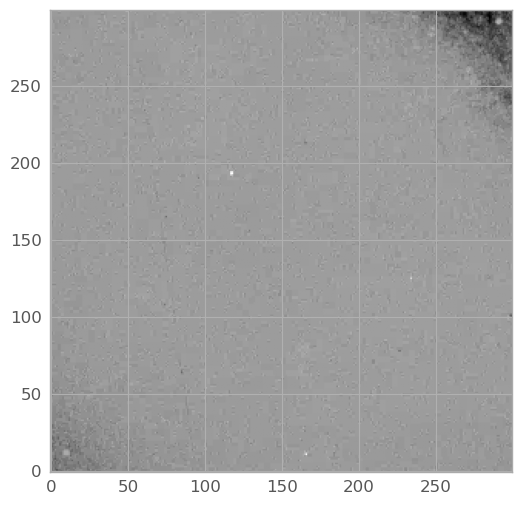

In [26]:
import numpy as np

plt.imshow(M31_Pixels, cmap='gray', origin='lower')

In [27]:
M31_Pixels[151, 151]

np.float32(11835.0)

In [28]:
print('Sumarray Statistics of M31 Pixels:-')
print(f'Minimum:- {np.min(M31_Pixels)}')
print(f'Maximum:- {np.max(M31_Pixels)}')
print(f'Average:- {np.mean(M31_Pixels)}')
print(f'Std:- {np.std(M31_Pixels)}')

Sumarray Statistics of M31 Pixels:-
Minimum:- 9237.0
Maximum:- 13481.0
Average:- 11793.09375
Std:- 182.15707397460938


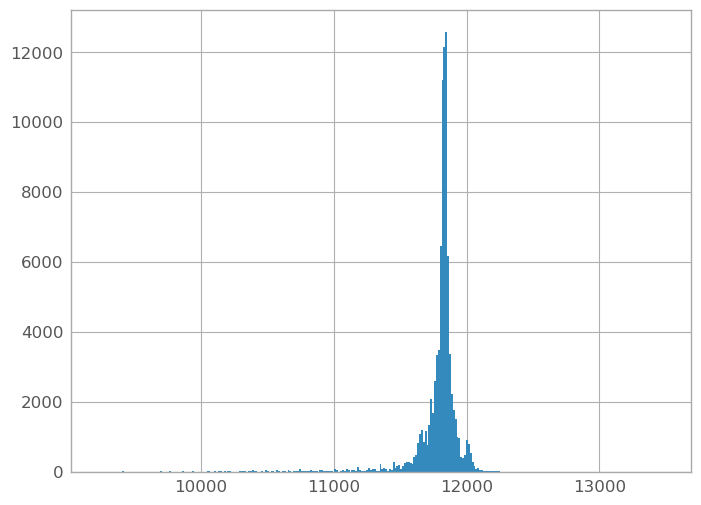

In [29]:
plt.hist(M31_Pixels.flat, bins=300)
plt.show()

In [30]:
# INTENSITY NORMALIZATION OR LINEAR SCALING OR MIN MAX SCALING

def plot_pixels(pixel_array, title, color):
  plt.imshow(pixel_array, cmap='gray', origin='lower')
  plt.title(title, color=color, weight='bold')
  plt.axis('off')

In [31]:
def compare_pixels(scaled_array, title):
  plt.subplot(1, 2, 1)
  plot_pixels(M31_Pixels, title='Original Image', color='black')
  plt.subplot(1, 2, 2)
  plot_pixels(scaled_array, title=title, color='royalblue')
  plt.tight_layout()
  plt.show()

In [32]:
def minmax_scaling(pixel_array):
  num = pixel_array - np.min(pixel_array)
  den = np.max(pixel_array) - np.min(pixel_array)
  return num/den

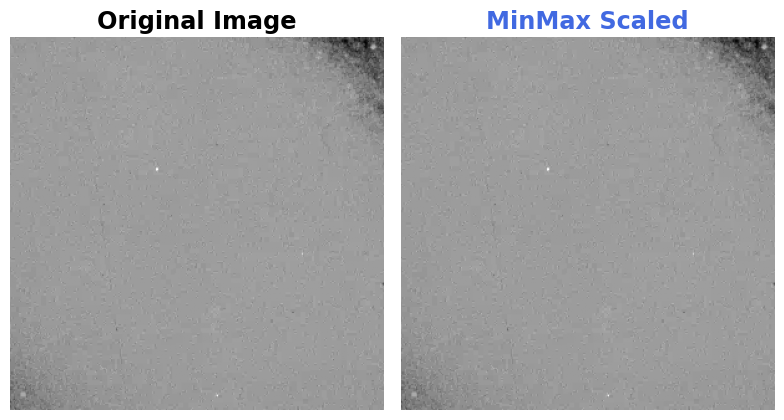

In [33]:
minmax_array = minmax_scaling(M31_Pixels)
compare_pixels(minmax_array, title='MinMax Scaled')

In [34]:
# A FUNCTION TO STANDARDIZE

def zscale(pixel_array):
  num = pixel_array - np.mean(pixel_array)
  den = np.std(pixel_array)
  return num/den

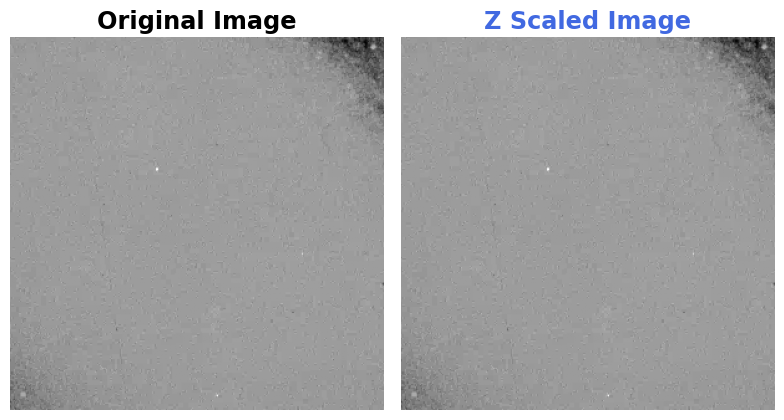

In [35]:
zscaled_array = zscale(M31_Pixels)
compare_pixels(zscaled_array, title='Z Scaled Image')

In [36]:
# LOG NORMALIZATION

def log_normalization(pixel_array):
  return np.log(pixel_array)

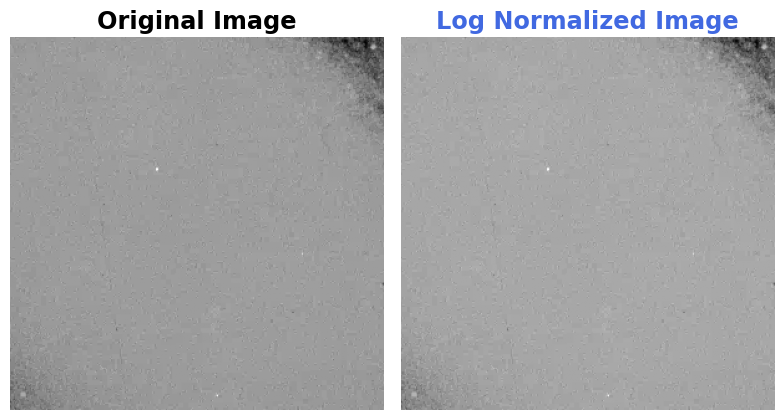

In [37]:
log_norm_array = log_normalization(M31_Pixels)
compare_pixels(log_norm_array, title='Log Normalized Image')

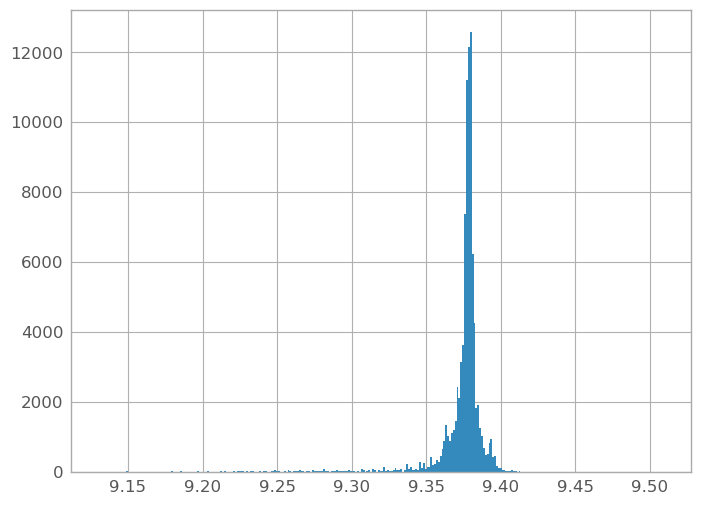

In [38]:
# CREATE A HISTOGRAM OF DISTRIBUTION OF PIXELS

plt.hist(log_norm_array.flat, bins=300)
plt.show()

In [39]:
log_norm_array.shape

(300, 300)

In [40]:
# SQUARE ROOT

def sqrt_scaling(pixel_array):
  return np.sqrt(pixel_array)

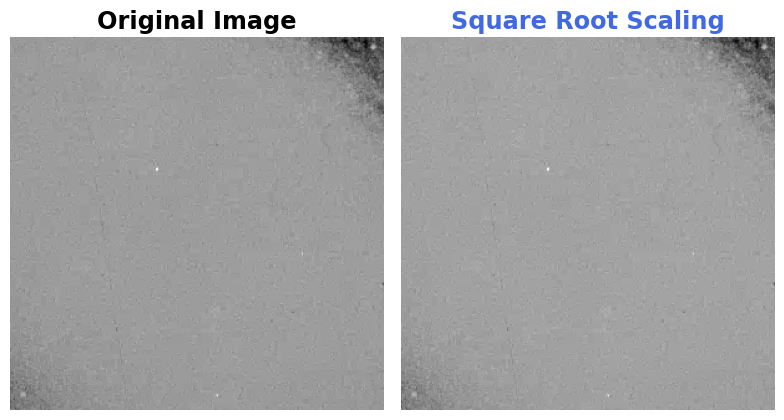

In [41]:
sqrt_array = sqrt_scaling(M31_Pixels)
compare_pixels(sqrt_array, title='Square Root Scaling')

In [ ]:
# ZSCALEINTERVAL

In [42]:
from astropy.visualization import ZScaleInterval

In [43]:
z = ZScaleInterval()

In [44]:
z1, z2 = z.get_limits(log_norm_array)

In [45]:
print(f'Minimum = {z1}')
print(f'Maximum = {z2}')

Minimum = 9.345743594590157
Maximum = 9.40335464477539


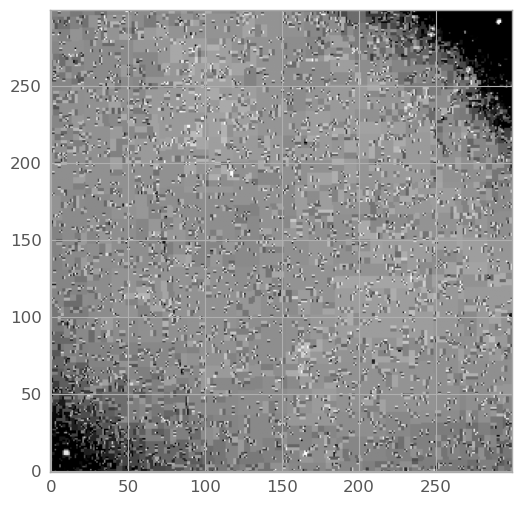

In [46]:
img = plt.imshow(log_norm_array, vmin=z1, vmax=z2, cmap='gray', origin='lower')
plt.show()

In [47]:
image_array = img.make_image(renderer=None, unsampled=True)[0]

In [48]:
image_array.shape

(300, 300, 4)

In [ ]:
# CHANGE 4 CHANNEL IMAGE TO GRAYSCALE

In [49]:
import cv2

In [50]:
gray_array = cv2.cvtColor(image_array, cv2.COLOR_BGRA2GRAY)

In [51]:
gray_array.shape

(300, 300)

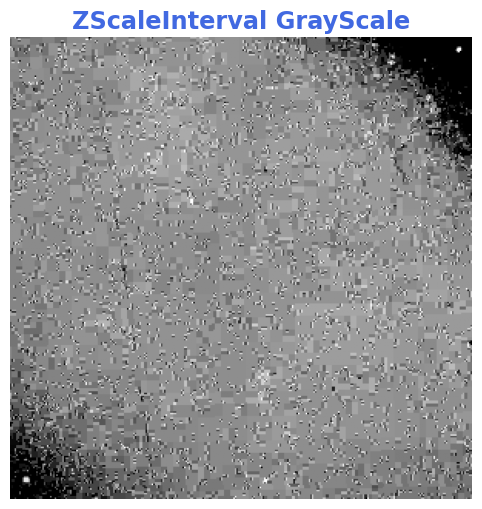

In [52]:
plot_pixels(gray_array, title='ZScaleInterval GrayScale', color='royalblue')

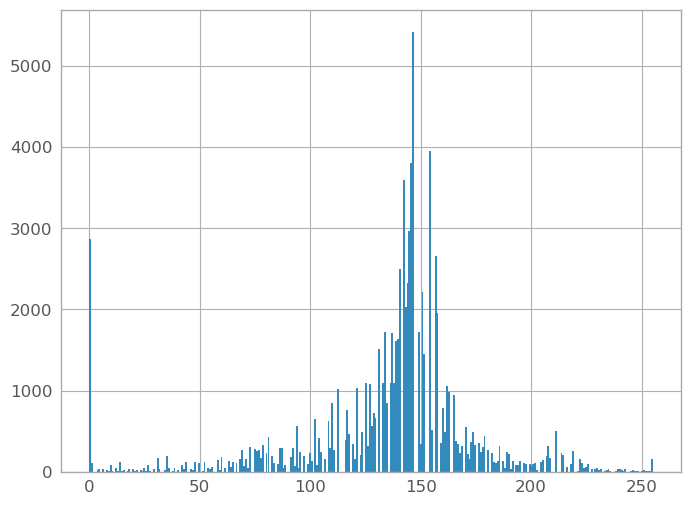

In [53]:
plt.hist(gray_array.flat, bins=300)
plt.show()

In [54]:
grayscale_zint_array = gray_array